# Exploratory Data Analysis — Telco Customer Churn
Goal: Understand the dataset deeply before writing any preprocessing or training code.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from preprocess import load_data

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 1. Load Data

In [2]:
df = load_data('../data/Telco_customer_churn.xlsx')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 2. Data Types and Basic Info

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [4]:
df[['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value', 'Churn Score', 'CLTV']].describe()

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,0.265370,58.699418,4400.295755
std,24.559481,30.090047,0.441561,21.525131,1183.057152
min,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,55.000000,89.850000,1.000000,75.000000,5380.500000
max,72.000000,118.750000,1.000000,100.000000,6500.000000


## 3. Columns We Will Drop

In [5]:
leakage_cols = ['Churn Score', 'CLTV', 'Churn Reason', 'Churn Label']
irrelevant_cols = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude']

print('Leakage columns (derived from churn — cannot use):')
print(leakage_cols)
print('\nIrrelevant columns (no predictive signal):')
print(irrelevant_cols)

Leakage columns (derived from churn — cannot use):
['Churn Score', 'CLTV', 'Churn Reason', 'Churn Label']

Irrelevant columns (no predictive signal):
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude']


## 4. Missing Values

In [6]:
missing = df.isnull().sum()
print('Columns with missing values:')
print(missing[missing > 0])

print(f'\nTotal Charges dtype: {df["Total Charges"].dtype}')

df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
missing_tc = df['Total Charges'].isnull().sum()
print(f'Rows with missing Total Charges after conversion: {missing_tc}')

Columns with missing values:
Churn Reason    5174
dtype: int64

Total Charges dtype: object
Rows with missing Total Charges after conversion: 11


In [7]:
# Inspect rows where Total Charges is missing
df[df['Total Charges'].isnull()][['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value']]

,Tenure Months,Monthly Charges,Total Charges,Churn Value
2234,0,52.55,NaN,0
2438,0,20.25,NaN,0
2568,0,80.85,NaN,0
2667,0,25.75,NaN,0
2856,0,56.05,NaN,0
4331,0,19.85,NaN,0
4687,0,25.35,NaN,0
5104,0,20.00,NaN,0
5719,0,19.70,NaN,0
6772,0,73.35,NaN,0


**Observation:** Missing Total Charges rows have Tenure Months = 0. New customers with no billing yet. We drop these rows.

## 5. Class Balance — Churn Distribution

Churn counts:
Churn Value
0    5174
1    1869
Name: count, dtype: int64

Churn percentage:
Churn Value
0    73.46
1    26.54
Name: proportion, dtype: float64


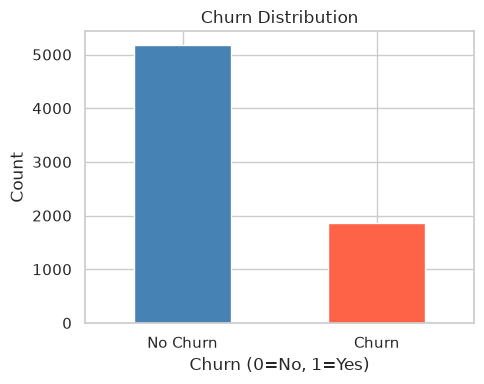

In [8]:
churn_counts = df['Churn Value'].value_counts()
churn_pct = df['Churn Value'].value_counts(normalize=True) * 100

print('Churn counts:')
print(churn_counts)
print('\nChurn percentage:')
print(churn_pct.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
churn_counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Churn Distribution')
ax.set_xlabel('Churn (0=No, 1=Yes)')
ax.set_ylabel('Count')
ax.set_xticklabels(['No Churn', 'Churn'], rotation=0)
plt.tight_layout()
plt.show()

## 6. Numerical Feature Distributions by Churn

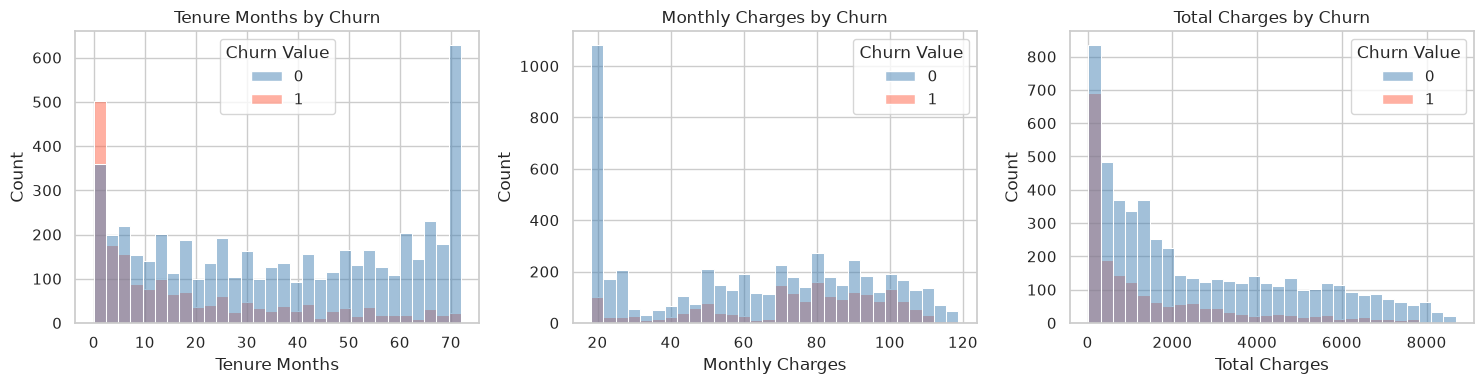

In [9]:
numerical_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, hue='Churn Value', bins=30, ax=axes[i], palette=['steelblue', 'tomato'])
    axes[i].set_title(f'{col} by Churn')

plt.tight_layout()
plt.show()

## 7. Categorical Features vs Churn Rate

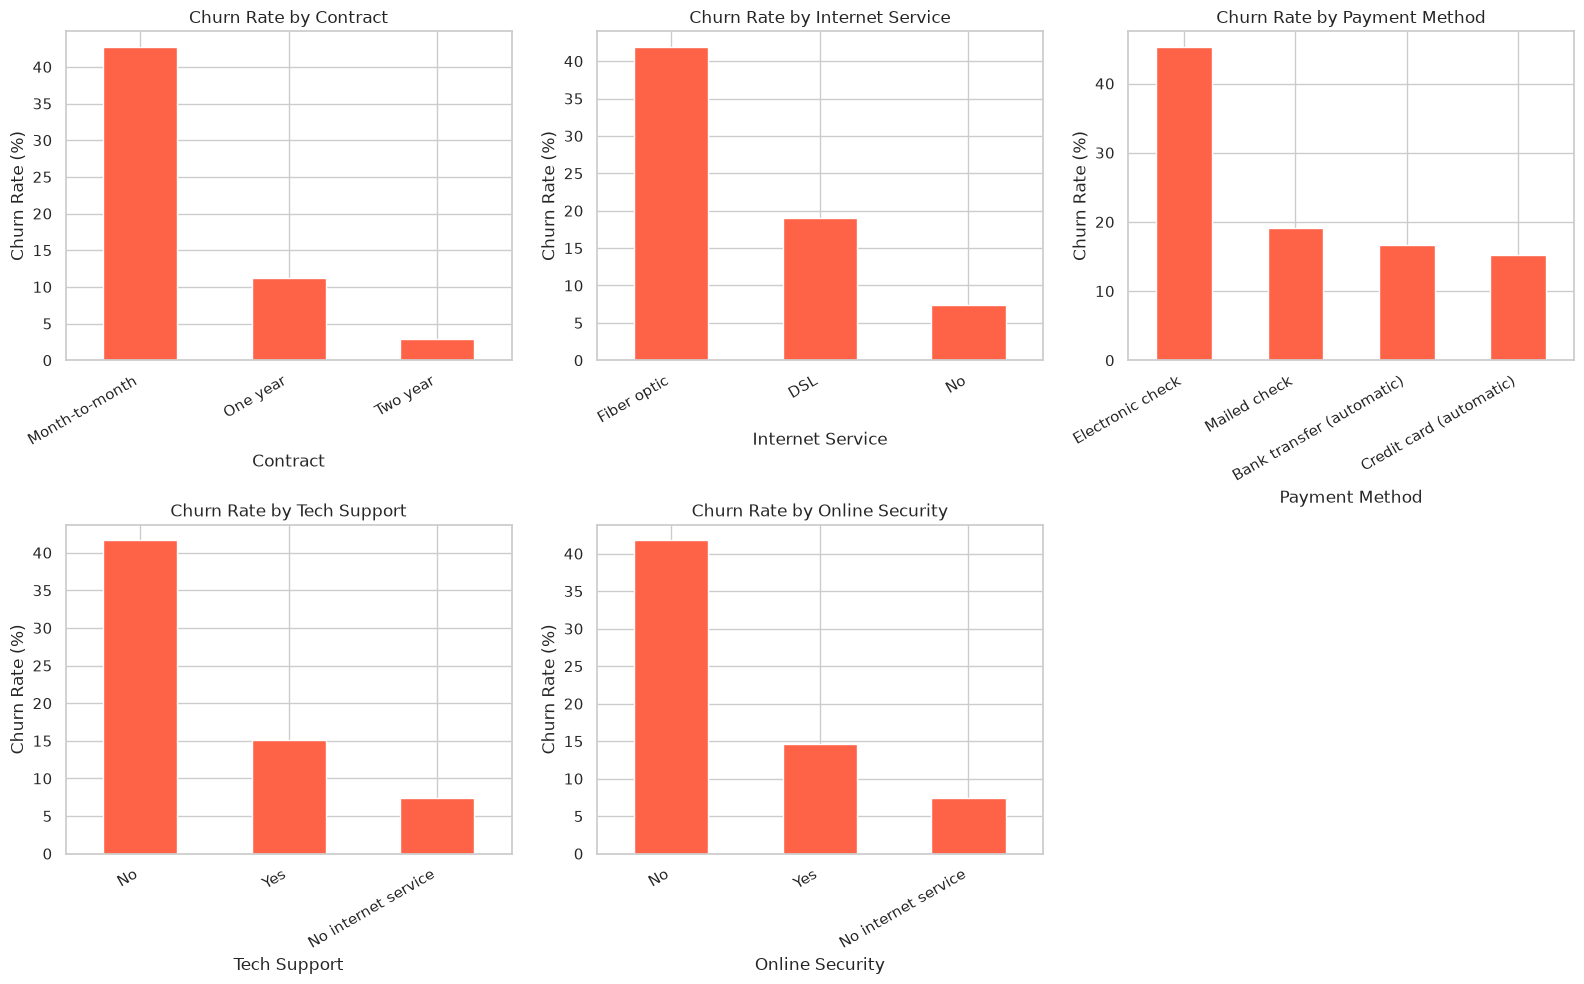

In [10]:
categorical_cols = ['Contract', 'Internet Service', 'Payment Method', 'Tech Support', 'Online Security']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['Churn Value'].mean() * 100
    churn_rate.sort_values(ascending=False).plot(kind='bar', ax=axes[i], color='tomato')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

## 8. Tenure vs Churn — Boxplot

/tmp/ipykernel_310525/2602347499.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn Value', y='Tenure Months', palette=['steelblue', 'tomato'], ax=ax)
/tmp/ipykernel_310525/2602347499.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No Churn', 'Churn'])


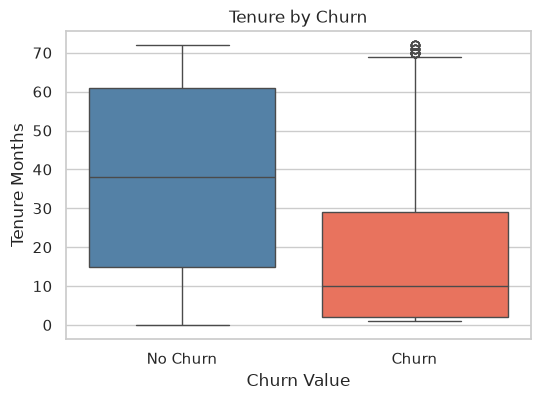

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x='Churn Value', y='Tenure Months', palette=['steelblue', 'tomato'], ax=ax)
ax.set_title('Tenure by Churn')
ax.set_xticklabels(['No Churn', 'Churn'])
plt.show()

## 9. Correlation Heatmap

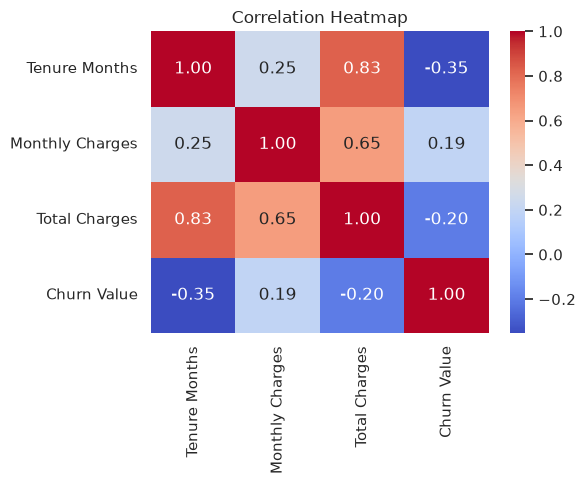

In [12]:
df_numeric = df[['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value']].copy()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 10. EDA Summary

| Finding | Action |
|---|---|
| Churn Score, CLTV, Churn Reason are derived from churn | Drop — data leakage |
| Location columns have no predictive signal | Drop |
| Total Charges is stored as object type | Convert to numeric, drop missing rows |
| Imbalanced classes (~73% No Churn, ~27% Churn) | Use class_weight and scale_pos_weight |
| Churners have much lower Tenure Months | Tenure Months is a strong feature |
| Month-to-month contract has highest churn rate | Contract is a strong feature |
| Fiber optic customers churn more | Internet Service is a strong feature |
| Total Charges highly correlated with Tenure Months | Expected — total = monthly x months |